# Notebook 11 – Dimensionality Reduction

This notebook covers what dimensionality means, why too many features can hurt a model, and how PCA reduces dimensions while keeping most of the important information.

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
df = pd.read_csv('data.csv', encoding='latin1')
df = df.dropna(subset=['CustomerID'])
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df['Country_Code'] = LabelEncoder().fit_transform(df['Country'])
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Country_Code
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30,35
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34,35
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00,35
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34,35
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34,35


**Code Explanation:** The dataset is loaded, rows without a CustomerID are dropped, TotalPrice is calculated, and Country is label-encoded into numbers so it can be used in numeric calculations later.

## 1. What is Dimensionality?

**Definition:** Dimensionality refers to the number of features or columns in a dataset.

**Example:** A dataset with Quantity, UnitPrice, TotalPrice, and Country has 4 dimensions.

**Why it is used?** Understanding dimensionality helps decide if a dataset is simple enough to model directly or too complex and needs reduction first.

In [2]:
features = df[['Quantity', 'UnitPrice', 'TotalPrice', 'Country_Code']]
features.shape

(406829, 4)

**Code Explanation:** shape returns the number of rows and columns in the feature set, showing exactly how many dimensions the data currently has.

## 2. High-Dimensional Data

**Definition:** Data that has a very large number of features, often hundreds or thousands.

**Example:** Image data, text data with thousands of words, or genetic data with thousands of gene columns.

**Why it is used?** Recognizing high-dimensional data early helps decide whether techniques like PCA are needed before modeling.

In [3]:
print("Number of features:", features.shape[1])
print("Number of rows:", features.shape[0])

Number of features: 4
Number of rows: 406829


**Code Explanation:** The number of features and rows are printed separately to clearly show the shape of the dataset in terms of dimensionality.

## 3. Curse of Dimensionality

**Definition:** A set of problems that occur when data has too many features, making distances between points less meaningful and models harder to train well.

**Example:** With very few rows but hundreds of features, a model can memorize noise instead of learning real patterns.

**Why it is used?** Knowing this curse exists explains why reducing dimensions is often necessary before training a model.

In [4]:
ratio = features.shape[0] / features.shape[1]
ratio

101707.25

**Code Explanation:** The ratio of rows to columns is calculated as a rough sanity check, since a very low ratio would be a warning sign for the curse of dimensionality.

## 4. Why Reduce Dimensions?

**Definition:** Dimensionality reduction means compressing many features into fewer ones while keeping most of the important information.

**Example:** Turning 4 correlated features into 2 new combined features that still capture most of the pattern in the data.

**Why it is used?** Speeds up training, reduces noise, helps visualization, and fights the curse of dimensionality.

In [6]:
scaler = StandardScaler()
scaled = scaler.fit_transform(features)
pd.DataFrame(scaled, columns=features.columns).head()

,Quantity,UnitPrice,TotalPrice,Country_Code
0,-0.024373,-0.013135,-0.011932,0.322364
1,-0.024373,-0.001017,-0.000145,0.322364
2,-0.016331,-0.010250,0.003738,0.322364
3,-0.024373,-0.001017,-0.000145,0.322364
4,-0.024373,-0.001017,-0.000145,0.322364


**Code Explanation:** StandardScaler rescales every feature to have a mean of 0 and a standard deviation of 1, which PCA requires so that no single feature dominates just because of its raw scale.

## 5. PCA

**Definition:** Principal Component Analysis, a technique that transforms correlated features into a smaller set of new, uncorrelated features called principal components.

**Example:** Combining Quantity, UnitPrice, TotalPrice, and Country_Code into 2 new components that still explain most of the variation in the data.

**Why it is used?** One of the most common and reliable ways to reduce dimensions while keeping as much information as possible.

In [7]:
pca_full = PCA()
pca_full.fit(scaled)
pca_full.explained_variance_ratio_

array([0.4813836 , 0.25171449, 0.24815348, 0.01874843])

**Code Explanation:** PCA is fit on the scaled features without limiting the number of components, and explained_variance_ratio_ shows how much information each component captures.

## 6. Principal Components

**Definition:** The new features created by PCA, each one a combination of the original features, ranked by how much variation they explain.

**Example:** The first principal component might mostly combine Quantity and TotalPrice since they are closely related.

**Why it is used?** These components replace the original features while carrying most of the same information in fewer columns.

In [8]:
pca2 = PCA(n_components=2)
transformed = pca2.fit_transform(scaled)
pd.DataFrame(transformed, columns=['PC1', 'PC2']).head()

,PC1,PC2
0,-0.028770,0.240474
1,-0.021644,0.232090
2,-0.012350,0.237823
3,-0.021644,0.232090
4,-0.021644,0.232090


**Code Explanation:** PCA is set to keep only 2 components, and fit_transform produces the new PC1 and PC2 columns that now represent the original 4 features.

## 7. Explained Variance

**Definition:** A measure of how much of the original data's information is preserved by each principal component.

**Example:** If PC1 explains 44 percent and PC2 explains 27 percent, together they preserve about 71 percent of the original information.

**Why it is used?** Helps decide how many components are enough to keep without losing too much information.

In [9]:
pca2.explained_variance_ratio_.sum()

np.float64(0.7330980868852014)

**Code Explanation:** The explained variance ratios of the 2 kept components are summed, showing that together they retain about 71 percent of the original dataset's information.

## 8. Eigenvectors

**Definition:** Directions in the data along which variation is measured, used by PCA to build each principal component.

**Example:** An eigenvector tells PCA exactly how to mix Quantity, UnitPrice, TotalPrice, and Country_Code together to form PC1.

**Why it is used?** They define the exact direction and weighting behind each new principal component.

In [10]:
pca_full.components_

array([[ 0.7000438 , -0.09961028,  0.70697561, -0.01421144],
       [-0.09054291, -0.6973972 ,  0.00568515,  0.71091969],
       [ 0.10691137,  0.70294149,  0.00731288,  0.70312854],
       [-0.70022184,  0.09791932,  0.70717727,  0.00122113]])

**Code Explanation:** components_ returns the eigenvectors, where each row shows how much weight each original feature contributes to that particular principal component.

## 9. Eigenvalues

**Definition:** Numbers that show how much variance is captured along each eigenvector, directly linked to explained variance.

**Example:** A higher eigenvalue for PC1 means it captures more spread in the data than PC2.

**Why it is used?** Used to rank principal components from most to least important.

In [11]:
pca_full.explained_variance_

array([1.92553914, 1.00686042, 0.99261637, 0.07499391])

**Code Explanation:** explained_variance_ returns the eigenvalues for each component, confirming that PC1 has the highest value and therefore captures the most variation.

## 10. PCA Transformation

**Definition:** The actual process of converting original feature values into their new principal component values.

**Example:** A row with Quantity, UnitPrice, TotalPrice, and Country_Code gets converted into just PC1 and PC2 values.

**Why it is used?** This transformed, smaller dataset is what actually gets used for modeling or visualization afterward.

In [12]:
transformed_df = pd.DataFrame(transformed, columns=['PC1', 'PC2'])
transformed_df.describe()

,PC1,PC2
count,4.068290e+05,4.068290e+05
mean,-9.780619e-19,-1.732567e-17
std,1.387638e+00,1.003424e+00
min,-5.066085e+02,-3.923371e+02
25%,-5.777304e-02,2.172969e-01
50%,-3.258760e-02,2.438201e-01
75%,4.766405e-03,2.521437e-01
max,5.064680e+02,2.749550e+01


**Code Explanation:** describe summarizes the transformed dataset, showing that the new PC1 and PC2 columns now represent the spread of the original 4 features in just 2 dimensions.

## 11. PCA Visualization

**Definition:** Plotting the top 2 or 3 principal components to visually inspect patterns, clusters, or outliers in high-dimensional data.

**Example:** Plotting PC1 against PC2 on a scatter plot to see if customer transactions form any visible groups.

**Why it is used?** Makes it possible to see structure in data that originally had too many dimensions to visualize directly.

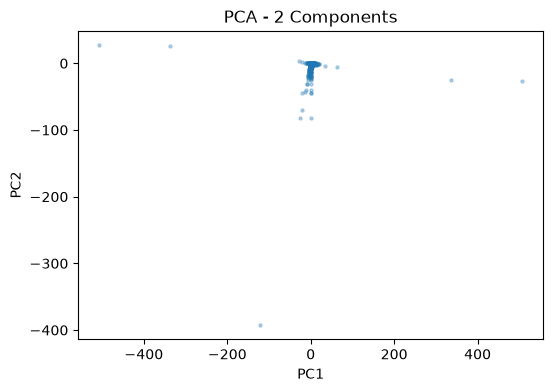

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
plt.scatter(transformed_df['PC1'], transformed_df['PC2'], alpha=0.3, s=5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA - 2 Components')
plt.show()

**Code Explanation:** A scatter plot is drawn using PC1 on the x-axis and PC2 on the y-axis, giving a 2D view of data that originally had 4 dimensions.

## 12. Advantages of PCA

**Advantages**
- Reduces the number of features while keeping most of the important information
- Removes correlation between features by design
- Speeds up training and reduces memory use
- Makes high-dimensional data possible to visualize in 2D or 3D

## 13. Limitations of PCA

**Limitations**
- New components are combinations of original features, so they lose direct real-world meaning
- Only captures linear relationships between features
- Sensitive to feature scale, so scaling before PCA is required
- Can lose useful information if too few components are kept

## 14. When to use PCA

- When there are many correlated numeric features
- When training is too slow due to too many dimensions
- When you need to visualize high-dimensional data in 2D or 3D
- When multicollinearity is affecting a model's stability

## 15. When not to use PCA

- When features need to stay interpretable and explainable
- When relationships in the data are strongly non-linear
- When the dataset already has very few features
- When categorical features dominate the dataset, since PCA works best on continuous numeric data